# Notebook 04 - BPM Estimation

## Objective
Estimate heart rate (BPM) from ECG signals using detected R-peaks and analyze RR intervals.

## Method
This notebook performs:
- ECG loading
- preprocessing inspired by Pan-Tompkins
- R-peak detection
- RR interval calculation
- instantaneous BPM estimation
- moving-average BPM smoothing
- simple BPM classification


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

In [2]:
# Adjust this path if needed
file_path = '../data/processed/cnn_X.npy'
fs = 200  # Hz

In [3]:
if not os.path.exists(file_path):
    raise FileNotFoundError(f'File not found: {file_path}')

ecg_data = np.load(file_path)

print('Original shape:', ecg_data.shape)
print('Dtype:', ecg_data.dtype)

Original shape: (23005, 3600)
Dtype: float32


In [4]:
if ecg_data.ndim == 1:
    ecg_signal = ecg_data
elif ecg_data.ndim == 2:
    ecg_signal = ecg_data[0]
elif ecg_data.ndim == 3:
    ecg_signal = ecg_data[0, :, 0]
else:
    raise ValueError(f'Unsupported shape: {ecg_data.shape}')

ecg_signal = np.asarray(ecg_signal).astype(float)
t = np.arange(len(ecg_signal)) / fs
duration = len(ecg_signal) / fs

print('Selected ECG shape:', ecg_signal.shape)
print(f'Duration: {duration:.2f} s')

Selected ECG shape: (3600,)
Duration: 18.00 s


In [5]:
def bandpass_filter(signal, lowcut=5, highcut=15, fs=200, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

ecg_band = bandpass_filter(ecg_signal, lowcut=5, highcut=15, fs=fs, order=2)
ecg_derivative = np.gradient(ecg_band)
ecg_squared = ecg_derivative ** 2

window_ms = 150
window_samples = int((window_ms / 1000) * fs)
window_samples = max(window_samples, 1)

kernel = np.ones(window_samples) / window_samples
ecg_integrated = np.convolve(ecg_squared, kernel, mode='same')

threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
min_distance_samples = int(0.3 * fs)

peaks, properties = find_peaks(
    ecg_integrated,
    height=threshold,
    distance=min_distance_samples
)

print(f'Detected peaks: {len(peaks)}')
print(f'Threshold: {threshold:.4f}')

Detected peaks: 13
Threshold: 0.0914


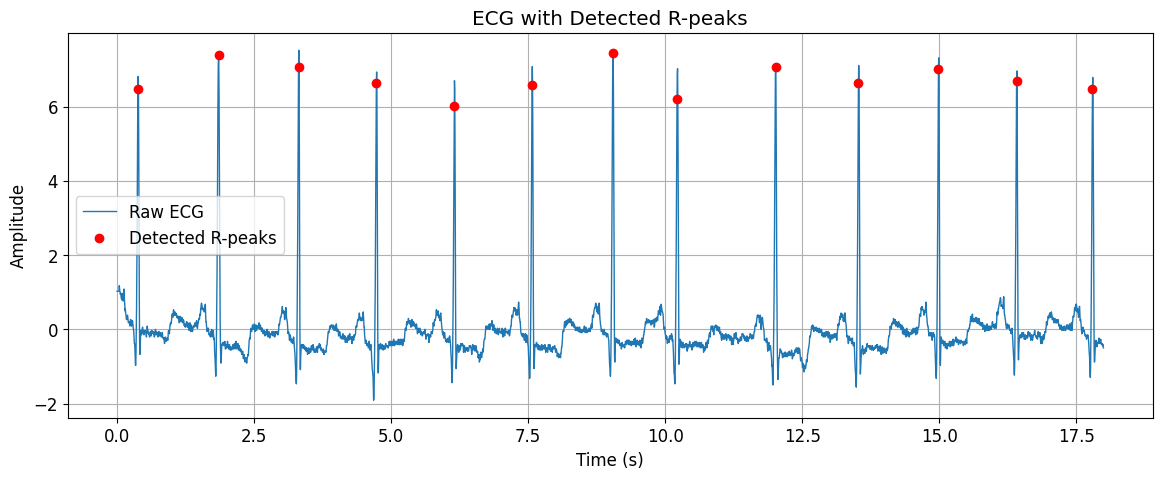

In [6]:
plt.figure()
plt.plot(t, ecg_signal, label='Raw ECG', linewidth=1)
plt.plot(t[peaks], ecg_signal[peaks], 'ro', label='Detected R-peaks')
plt.title('ECG with Detected R-peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
if len(peaks) < 2:
    raise ValueError('Not enough peaks detected to estimate BPM.')

rr_intervals_s = np.diff(t[peaks])
rr_intervals_ms = rr_intervals_s * 1000
bpm_inst = 60 / rr_intervals_s

print('First RR intervals (ms):', rr_intervals_ms[:10])
print('First instantaneous BPM values:', bpm_inst[:10])

First RR intervals (ms): [1470. 1460. 1420. 1420. 1420. 1475. 1170. 1800. 1510. 1460.]
First instantaneous BPM values: [40.81632653 41.09589041 42.25352113 42.25352113 42.25352113 40.6779661
 51.28205128 33.33333333 39.73509934 41.09589041]


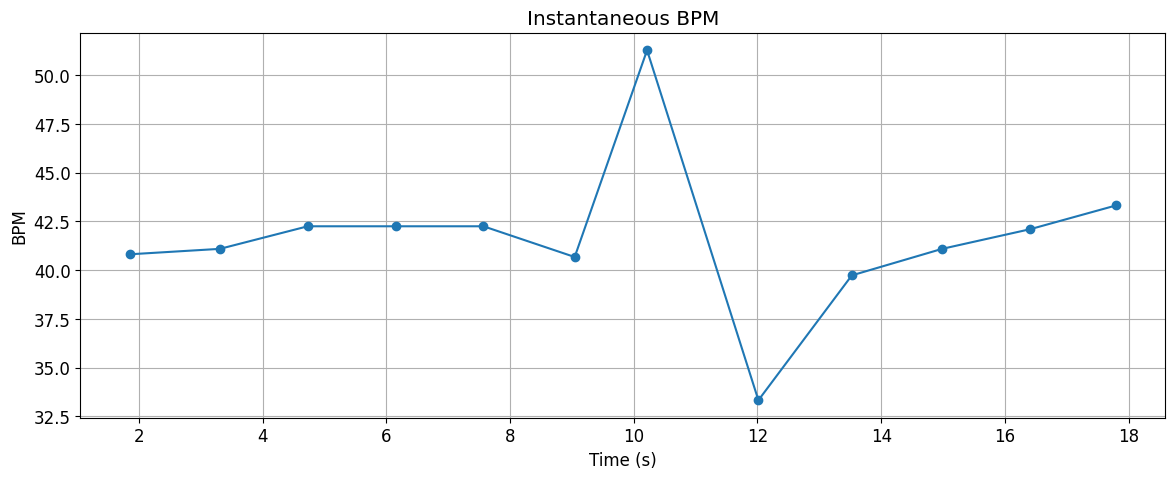

In [8]:
bpm_time = t[peaks][1:]

plt.figure()
plt.plot(bpm_time, bpm_inst, marker='o')
plt.title('Instantaneous BPM')
plt.xlabel('Time (s)')
plt.ylabel('BPM')
plt.grid(True)
plt.show()

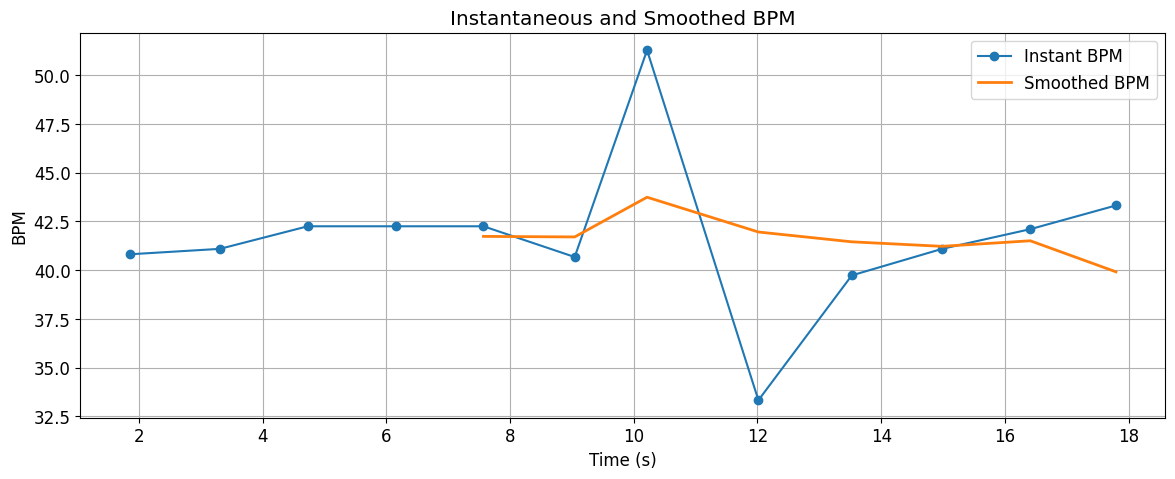

In [9]:
smooth_window = 5

if len(bpm_inst) >= smooth_window:
    bpm_smooth = np.convolve(bpm_inst, np.ones(smooth_window)/smooth_window, mode='valid')
    bpm_smooth_time = bpm_time[smooth_window-1:]
else:
    bpm_smooth = bpm_inst.copy()
    bpm_smooth_time = bpm_time.copy()

plt.figure()
plt.plot(bpm_time, bpm_inst, marker='o', label='Instant BPM')
plt.plot(bpm_smooth_time, bpm_smooth, linewidth=2, label='Smoothed BPM')
plt.title('Instantaneous and Smoothed BPM')
plt.xlabel('Time (s)')
plt.ylabel('BPM')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
bpm_mean = np.mean(bpm_inst)
bpm_median = np.median(bpm_inst)
bpm_std = np.std(bpm_inst)
rr_mean_ms = np.mean(rr_intervals_ms)
rr_std_ms = np.std(rr_intervals_ms)

print(f'Mean BPM: {bpm_mean:.2f}')
print(f'Median BPM: {bpm_median:.2f}')
print(f'BPM std: {bpm_std:.2f}')
print(f'Mean RR (ms): {rr_mean_ms:.2f}')
print(f'RR std (ms): {rr_std_ms:.2f}')

Mean BPM: 41.69
Median BPM: 41.60
BPM std: 3.79
Mean RR (ms): 1451.25
RR std (ms): 133.31


In [11]:
def classify_bpm(mean_bpm):
    if mean_bpm < 60:
        return 'Possible bradycardia'
    elif mean_bpm > 100:
        return 'Possible tachycardia'
    else:
        return 'Normal resting range'

classification = classify_bpm(bpm_mean)
print('Classification:', classification)

Classification: Possible bradycardia


In [12]:
summary = pd.DataFrame({
    'Metric': [
        'Duration (s)',
        'Detected peaks',
        'Mean BPM',
        'Median BPM',
        'BPM std',
        'Mean RR (ms)',
        'RR std (ms)',
        'Classification'
    ],
    'Value': [
        duration,
        len(peaks),
        bpm_mean,
        bpm_median,
        bpm_std,
        rr_mean_ms,
        rr_std_ms,
        classification
    ]
})

summary

,Metric,Value
0,Duration (s),18.0
1,Detected peaks,13
2,Mean BPM,41.685307
3,Median BPM,41.600577
4,BPM std,3.785305
5,Mean RR (ms),1451.25
6,RR std (ms),133.309243
7,Classification,Possible bradycardia


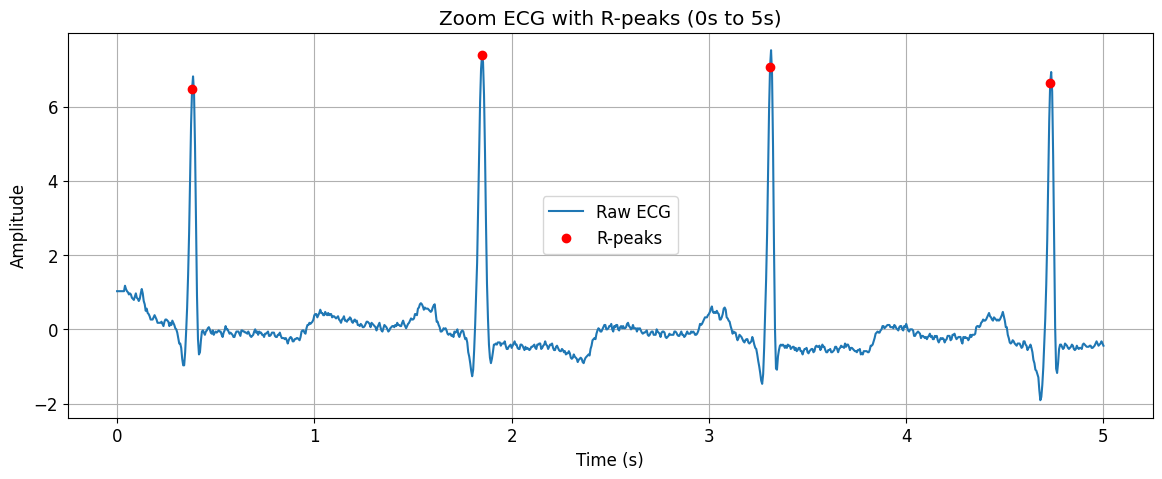

In [13]:
zoom_start_s = 0
zoom_end_s = min(5, duration)

mask = (t >= zoom_start_s) & (t <= zoom_end_s)
peak_mask = (t[peaks] >= zoom_start_s) & (t[peaks] <= zoom_end_s)

plt.figure()
plt.plot(t[mask], ecg_signal[mask], label='Raw ECG')
plt.plot(t[peaks][peak_mask], ecg_signal[peaks][peak_mask], 'ro', label='R-peaks')
plt.title(f'Zoom ECG with R-peaks ({zoom_start_s}s to {zoom_end_s}s)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

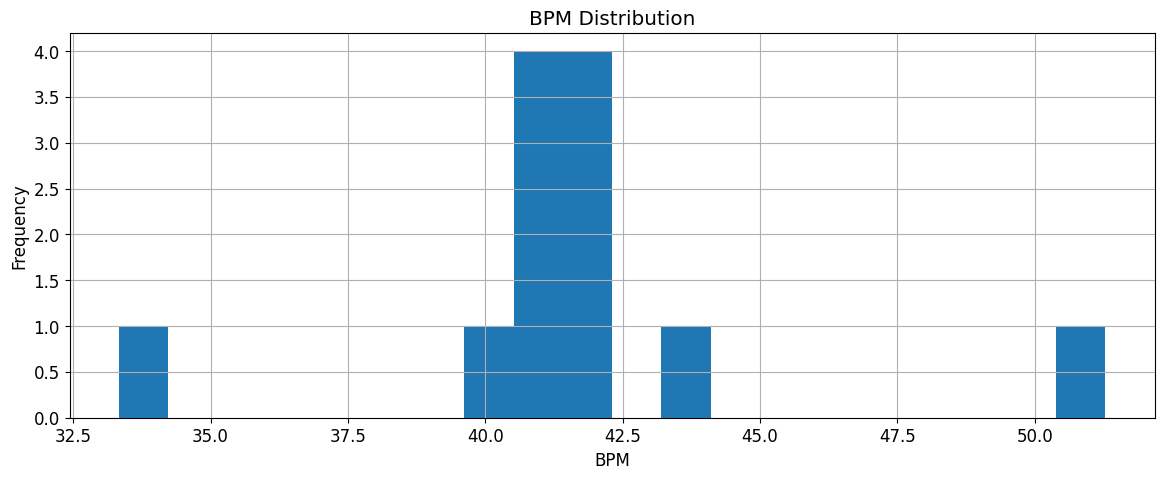

In [14]:
plt.figure()
plt.hist(bpm_inst, bins=20)
plt.title('BPM Distribution')
plt.xlabel('BPM')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [15]:
print('Notebook 04 - BPM Estimation completed successfully.')
print('Outputs generated:')
print('- R-peak positions')
print('- RR intervals')
print('- Instantaneous BPM')
print('- Smoothed BPM')
print('- Basic rhythm classification')

Notebook 04 - BPM Estimation completed successfully.
Outputs generated:
- R-peak positions
- RR intervals
- Instantaneous BPM
- Smoothed BPM
- Basic rhythm classification
